# Inference-Based Multi-Dimensional Negotiation

Two agents negotiate a B2B software contract by exchanging **full counteroffers** across all 5 dimensions each round. No mediator, no fixed step sizes.

The critical twist: each agent must **infer the other side's priorities** from observed proposal history alone, maintaining a structured 1-5 ranking each round, then trade strategically (concede on what they think the other side cares about, hold firm on what they think the other side does not).

```
Round 1: Buyer proposes full terms
Round 2: Seller counteroffers (or accepts buyer's proposal)
Round 3: Buyer counteroffers (or accepts seller's proposal)
...
Until accept or max 20 rounds -> close on last proposal
```

In [88]:
# ── Imports & .env loading ──────────────────────────────────────────────────

import os, pathlib, json, re, copy
from dataclasses import dataclass, field
from openai import OpenAI
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
import pandas as pd

_env = pathlib.Path(".") / ".env"
if _env.exists():
    for _line in _env.read_text().splitlines():
        if _line.strip() and not _line.startswith("#") and "=" in _line:
            _k, _v = _line.split("=", 1)
            os.environ.setdefault(_k.strip(), _v.strip())

print("Environment ready")

Environment ready


## Term Sheets
Each side has **private** priorities and walk-away limits. Agents see only their own term sheet, never the other's weights or ranking.

In [89]:
BUYER_TERM_SHEET = {
    "role": "Buyer",
    "description": "You are purchasing a custom software platform.",
    "priority_ranking": ["price", "warranty_months", "payment_terms", "delivery_weeks", "support_hours"],
    "priorities": (
        "1) price (MUST be low - your #1 issue), "
        "2) warranty_months (longer is much better), "
        "3) payment_terms (longer is better), "
        "4) delivery_weeks (flexible - low priority), "
        "5) support_hours (barely care)"
    ),
    "limits": {
        "price":           {"walk_away": 90_000, "target": 65_000},
        "delivery_weeks":  {"walk_away": 20,     "target": 10},
        "payment_terms":   {"acceptable": ["net30", "net40", "net50", "net60", "net70", "net80", "net90"], "target": "net60"},
        "warranty_months": {"walk_away": 6,  "target": 24},
        "support_hours":   {"walk_away": 20, "target": 160},
    },
}

SELLER_TERM_SHEET = {
    "role": "Seller",
    "description": "You are selling a custom software platform.",
    "priority_ranking": ["delivery_weeks", "support_hours", "price", "payment_terms", "warranty_months"],
    "priorities": (
        "1) delivery_weeks (MUST have enough time - your #1 issue), "
        "2) support_hours (fewer included hours is much better - limits unpaid scope), "
        "3) price (higher is better), "
        "4) payment_terms (flexible), "
        "5) warranty_months (barely care)"
    ),
    "limits": {
        "price":           {"walk_away": 60_000, "target": 80_000},
        "delivery_weeks":  {"walk_away": 8,      "target": 16},
        "payment_terms":   {"acceptable": ["net30", "net40", "net50", "net60", "net70", "net80", "net90"], "target": "net30"},
        "warranty_months": {"walk_away": 24, "target": 6},
        "support_hours":   {"walk_away": 200, "target": 40},
    },
}

rows = [
    ("Price",          "***** #1", f"${BUYER_TERM_SHEET['limits']['price']['target']:,}",          f"${BUYER_TERM_SHEET['limits']['price']['walk_away']:,}",
                       "** #3",    f"${SELLER_TERM_SHEET['limits']['price']['target']:,}",         f"${SELLER_TERM_SHEET['limits']['price']['walk_away']:,}"),
    ("Warranty (mo)",  "**** #2",  str(BUYER_TERM_SHEET['limits']['warranty_months']['target']),   str(BUYER_TERM_SHEET['limits']['warranty_months']['walk_away']),
                       "* #5",     str(SELLER_TERM_SHEET['limits']['warranty_months']['target']),  str(SELLER_TERM_SHEET['limits']['warranty_months']['walk_away'])),
    ("Payment terms",  "*** #3",   BUYER_TERM_SHEET['limits']['payment_terms']['target'],          "net30 (min)",
                       "** #4",    SELLER_TERM_SHEET['limits']['payment_terms']['target'],         "net90 (min)"),
    ("Delivery weeks", "* #4",     str(BUYER_TERM_SHEET['limits']['delivery_weeks']['target']),    str(BUYER_TERM_SHEET['limits']['delivery_weeks']['walk_away']),
                       "***** #1", str(SELLER_TERM_SHEET['limits']['delivery_weeks']['target']),   str(SELLER_TERM_SHEET['limits']['delivery_weeks']['walk_away'])),
    ("Support hours",  "* #5",     str(BUYER_TERM_SHEET['limits']['support_hours']['target']),     str(BUYER_TERM_SHEET['limits']['support_hours']['walk_away']),
                       "**** #2",  str(SELLER_TERM_SHEET['limits']['support_hours']['target']),    str(SELLER_TERM_SHEET['limits']['support_hours']['walk_away'])),
]

df = pd.DataFrame(rows, columns=[
    "Dimension",
    "Buyer priority", "Buyer target", "Buyer walk-away",
    "Seller priority", "Seller target", "Seller walk-away",
]).set_index("Dimension")

display(df.style
    .set_caption("Private Term Sheets - asymmetric priorities create Pareto trades")
    .set_table_styles([{"selector": "th", "props": [("background-color", "#2d2d2d"), ("color", "white"), ("font-weight", "bold")]}])
)

,Buyer priority,Buyer target,Buyer walk-away,Seller priority,Seller target,Seller walk-away
Dimension,,,,,,
Price,***** #1,"$65,000","$90,000",** #3,"$80,000","$60,000"
Warranty (mo),**** #2,24,6,* #5,6,24
Payment terms,*** #3,net60,net30 (min),** #4,net30,net90 (min)
Delivery weeks,* #4,10,20,***** #1,16,8
Support hours,* #5,160,20,**** #2,40,200


In [90]:
# ── Inference negotiation protocol ─────────────────────────────────────────

MAX_ROUNDS = 50
DIMENSIONS = ("price", "delivery_weeks", "payment_terms", "warranty_months", "support_hours")
PAYMENT_ORDER = ["net30", "net40", "net50", "net60", "net70", "net80", "net90"]

BUYER_WEIGHTS  = {"price": 0.45, "warranty_months": 0.25, "payment_terms": 0.15, "delivery_weeks": 0.10, "support_hours": 0.05}
SELLER_WEIGHTS = {"delivery_weeks": 0.40, "support_hours": 0.30, "price": 0.15, "payment_terms": 0.10, "warranty_months": 0.05}

DIM_LABELS = {
    "price": "Price",
    "delivery_weeks": "Delivery",
    "payment_terms": "Payment",
    "warranty_months": "Warranty",
    "support_hours": "Support",
}

# Ground truth rankings (evaluation only — never shown to agents)
REAL_BUYER_RANKS = {dim: i + 1 for i, dim in enumerate(BUYER_TERM_SHEET["priority_ranking"])}
REAL_SELLER_RANKS = {dim: i + 1 for i, dim in enumerate(SELLER_TERM_SHEET["priority_ranking"])}

JSON_SCHEMA = (
    '{\n'
    '  "action": "propose" | "accept",\n'
    '  "terms": {\n'
    '    "price": <int>,\n'
    '    "delivery_weeks": <int>,\n'
    '    "payment_terms": "net30"|"net40"|...|"net90",\n'
    '    "warranty_months": <int>,\n'
    '    "support_hours": <int>\n'
    '  },\n'
    '  "my_reasoning": "<private: why you moved what you moved, max 2 sentences>",\n'
    '  "inference_about_other_side": "<private: brief narrative of what you think they care about>",\n'
    '  "inferred_other_priorities": {\n'
    '    "price": <1-5>,\n'
    '    "delivery_weeks": <1-5>,\n'
    '    "payment_terms": <1-5>,\n'
    '    "warranty_months": <1-5>,\n'
    '    "support_hours": <1-5>\n'
    '  }\n'
    '}'
)


def build_system_prompt(term_sheet: dict) -> str:
    """System prompt with inference instructions. Only exposes THIS party's private term sheet."""
    role = term_sheet["role"]
    other = "Seller" if role == "Buyer" else "Buyer"

    return (
        f"You are the {role} in a direct B2B software contract negotiation.\n\n"
        f"{term_sheet['description']}\n\n"
        "PROTOCOL:\n"
        "- Each turn you either PROPOSE a complete new set of terms (all 5 dimensions at once) or ACCEPT the other side's last proposal as-is.\n"
        f"- action: accept means you accept the {other}'s most recent proposal unchanged (not your own).\n"
        "- action: propose means you submit a full counteroffer across price, delivery_weeks, payment_terms, warranty_months, support_hours.\n"
        "- You decide how much to move each dimension. There is no mediator and no fixed step size.\n"
        "- You will see the FULL history of all proposals from both sides.\n"
        f"- You do NOT know the {other}'s term sheet, priority ranking, or utility weights. Infer them only from behavior.\n\n"
        "INFERENCE MECHANISM (critical):\n"
        "1. After round 1, study what the other side moved versus their previous proposal: which dimensions changed, which held firm, by how much.\n"
        "2. Build a running inference: e.g. they hold firm on X but concede easily on Y, so X is probably high priority for them, Y is low.\n"
        "3. Trade strategically: concede generously on dimensions you infer are HIGH priority for them (costs you little, buys goodwill).\n"
        "   Hold firm on dimensions you infer they do NOT care about (no point giving it away).\n"
        "4. Update your inference every round. inference_about_other_side must reflect THIS round's updated belief.\n"
        "5. Each round, output inferred_other_priorities: rank ALL 5 dimensions from the OTHER side's perspective (1=most important, 5=least).\n"
        "   Use each rank 1-5 exactly once. Update the ranking every round based on new evidence.\n\n"
        "YOUR PRIVATE INFORMATION (never reveal to the other side):\n"
        f"{term_sheet['priorities']}\n\n"
        f"Walk-away limits & targets: {json.dumps(term_sheet['limits'], indent=2)}\n\n"
        "Respond with valid JSON only:\n"
        f"{JSON_SCHEMA}\n\n"
        "Rules:\n"
        "- NEVER accept if any term in the other side's proposal is beyond your walk-away limits.\n"
        "- When proposing, stay within your own walk-away limits.\n"
        "- Round 1 (Buyer only): anchor your opening offer near your targets, not your walk-away limits.\n"
        "- Make trades: improve their high-priority dimensions (per your inference) while protecting yours."
    )


def _call_openai(client, system, messages, max_tokens=768):
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        max_tokens=max_tokens,
        messages=[{"role": "system", "content": system}, *messages],
    )
    raw = response.choices[0].message.content
    raw = re.sub(r"^```(?:json)?\s*|\s*```$", "", raw.strip())
    return json.loads(raw), raw


def _format_deal(terms: dict) -> str:
    return (
        f"price=${terms['price']:,}, "
        f"delivery={terms['delivery_weeks']}w, "
        f"payment={terms['payment_terms']}, "
        f"warranty={terms['warranty_months']}mo, "
        f"support={terms['support_hours']}h"
    )


def _clamp_terms(terms: dict, term_sheet: dict) -> dict:
    """Keep proposals within this party's walk-away limits."""
    lim = term_sheet["limits"]
    t = copy.deepcopy(terms)

    # Buyer wants low price; seller wants high price — clamp to own walk-away
    if term_sheet["role"] == "Buyer":
        t["price"] = int(max(lim["price"]["target"], min(lim["price"]["walk_away"], t.get("price", lim["price"]["target"]))))
        t["delivery_weeks"] = int(max(lim["delivery_weeks"]["target"], min(lim["delivery_weeks"]["walk_away"], t.get("delivery_weeks", lim["delivery_weeks"]["target"]))))
        t["warranty_months"] = int(max(lim["warranty_months"]["walk_away"], min(lim["warranty_months"]["target"], t.get("warranty_months", lim["warranty_months"]["target"]))))
        t["support_hours"] = int(max(lim["support_hours"]["walk_away"], min(lim["support_hours"]["target"], t.get("support_hours", lim["support_hours"]["target"]))))
    else:
        t["price"] = int(max(lim["price"]["walk_away"], min(lim["price"]["target"], t.get("price", lim["price"]["target"]))))
        t["delivery_weeks"] = int(max(lim["delivery_weeks"]["walk_away"], min(lim["delivery_weeks"]["target"], t.get("delivery_weeks", lim["delivery_weeks"]["target"]))))
        t["warranty_months"] = int(max(lim["warranty_months"]["target"], min(lim["warranty_months"]["walk_away"], t.get("warranty_months", lim["warranty_months"]["target"]))))
        t["support_hours"] = int(max(lim["support_hours"]["target"], min(lim["support_hours"]["walk_away"], t.get("support_hours", lim["support_hours"]["target"]))))

    pay = t.get("payment_terms", lim["payment_terms"]["target"])
    if pay not in PAYMENT_ORDER:
        pay = lim["payment_terms"]["target"]
    t["payment_terms"] = pay
    return t


def _normalize_inferred_ranking(raw: dict | None) -> dict[str, int]:
    """Ensure a valid 1-5 priority ranking (1=most important) for all dimensions."""
    default = {d: i + 1 for i, d in enumerate(DIMENSIONS)}
    if not raw or not isinstance(raw, dict):
        return default

    result = {}
    for d in DIMENSIONS:
        try:
            val = int(raw.get(d, 3))
        except (TypeError, ValueError):
            val = 3
        result[d] = max(1, min(5, val))

    # Fix duplicates by re-ranking dimensions by stated priority
    if len(set(result.values())) != 5:
        sorted_dims = sorted(DIMENSIONS, key=lambda d: (result[d], d))
        return {d: i + 1 for i, d in enumerate(sorted_dims)}
    return result


def _format_ranking(ranks: dict[str, int]) -> str:
    ordered = sorted(ranks.items(), key=lambda x: x[1])
    return " > ".join(f"{DIM_LABELS.get(d, d)}(#{r})" for d, r in ordered)


def _format_proposal_history(history: list[dict]) -> str:
    if not history:
        return "(no proposals yet)"
    lines = []
    for entry in history:
        lines.append(
            f"Round {entry['round']} | {entry['actor']} | {entry['action']} | {_format_deal(entry['terms'])}"
        )
    return "\n".join(lines)


def _payment_utility() -> dict[str, float]:
    n = len(PAYMENT_ORDER) - 1
    return {term: i * 100 / n for i, term in enumerate(PAYMENT_ORDER)}


def _dim_score(value, target, walk_away, higher_is_better: bool) -> float:
    if target == walk_away:
        return 50.0
    if higher_is_better:
        return max(0.0, min(100.0, (value - walk_away) / (target - walk_away) * 100))
    return max(0.0, min(100.0, (walk_away - value) / (walk_away - target) * 100))


def compute_party_utility(terms: dict, party: str) -> float:
    pay_val = _payment_utility()
    bl, sl = BUYER_TERM_SHEET["limits"], SELLER_TERM_SHEET["limits"]

    if party == "Buyer":
        dims = {
            "price":           _dim_score(terms["price"], bl["price"]["target"], bl["price"]["walk_away"], False),
            "warranty_months": _dim_score(terms["warranty_months"], bl["warranty_months"]["target"], bl["warranty_months"]["walk_away"], True),
            "payment_terms":   pay_val.get(terms["payment_terms"], 0),
            "delivery_weeks":  _dim_score(terms["delivery_weeks"], bl["delivery_weeks"]["target"], bl["delivery_weeks"]["walk_away"], False),
            "support_hours":   _dim_score(terms["support_hours"], bl["support_hours"]["target"], bl["support_hours"]["walk_away"], True),
        }
        weights = BUYER_WEIGHTS
    else:
        dims = {
            "delivery_weeks":  _dim_score(terms["delivery_weeks"], sl["delivery_weeks"]["target"], sl["delivery_weeks"]["walk_away"], True),
            "support_hours":   _dim_score(terms["support_hours"], sl["support_hours"]["target"], sl["support_hours"]["walk_away"], False),
            "price":           _dim_score(terms["price"], sl["price"]["target"], sl["price"]["walk_away"], True),
            "payment_terms":   100 - pay_val.get(terms["payment_terms"], 0),
            "warranty_months": _dim_score(terms["warranty_months"], sl["warranty_months"]["target"], sl["warranty_months"]["walk_away"], False),
        }
        weights = SELLER_WEIGHTS

    return sum(dims[d] * weights[d] for d in weights)


def score_outcome(terms):
    if not terms:
        return None

    buyer_total  = compute_party_utility(terms, "Buyer")
    seller_total = compute_party_utility(terms, "Seller")
    pay_val = _payment_utility()
    bl, sl = BUYER_TERM_SHEET["limits"], SELLER_TERM_SHEET["limits"]

    buyer_dims = {
        "price": _dim_score(terms["price"], bl["price"]["target"], bl["price"]["walk_away"], False),
        "warranty_months": _dim_score(terms["warranty_months"], bl["warranty_months"]["target"], bl["warranty_months"]["walk_away"], True),
        "payment_terms": pay_val.get(terms["payment_terms"], 0),
        "delivery_weeks": _dim_score(terms["delivery_weeks"], bl["delivery_weeks"]["target"], bl["delivery_weeks"]["walk_away"], False),
        "support_hours": _dim_score(terms["support_hours"], bl["support_hours"]["target"], bl["support_hours"]["walk_away"], True),
    }
    seller_dims = {
        "delivery_weeks": _dim_score(terms["delivery_weeks"], sl["delivery_weeks"]["target"], sl["delivery_weeks"]["walk_away"], True),
        "support_hours": _dim_score(terms["support_hours"], sl["support_hours"]["target"], sl["support_hours"]["walk_away"], False),
        "price": _dim_score(terms["price"], sl["price"]["target"], sl["price"]["walk_away"], True),
        "payment_terms": 100 - pay_val.get(terms["payment_terms"], 0),
        "warranty_months": _dim_score(terms["warranty_months"], sl["warranty_months"]["target"], sl["warranty_months"]["walk_away"], False),
    }

    return {
        "buyer_score": round(buyer_total, 1),
        "seller_score": round(seller_total, 1),
        "joint_surplus": round(buyer_total + seller_total, 1),
        "components": {"buyer": {k: round(v, 1) for k, v in buyer_dims.items()},
                       "seller": {k: round(v, 1) for k, v in seller_dims.items()}},
    }


@dataclass
class InferenceAgent:
    role: str
    term_sheet: dict
    client: OpenAI = field(default_factory=OpenAI)

    def act(self, round_num: int, proposal_history: list[dict], other_last: dict | None) -> dict:
        other = "Seller" if self.role == "Buyer" else "Buyer"
        system = build_system_prompt(self.term_sheet)

        if round_num == 1 and self.role == "Buyer":
            task = (
                f"Round {round_num}. You open the negotiation. Propose a complete opening offer "
                f"anchored near your targets (not walk-away limits). This is your first move."
            )
        elif other_last:
            task = (
                f"Round {round_num}. The {other}'s last proposal:\n"
                f"{json.dumps(other_last['terms'])}\n\n"
                f"Accept their proposal as-is, or propose a full counteroffer across all 5 dimensions."
            )
        else:
            task = f"Round {round_num}. Propose a complete offer."

        prompt = (
            f"{task}\n\n"
            f"FULL PROPOSAL HISTORY:\n{_format_proposal_history(proposal_history)}\n\n"
            "Study the other side's moves and update both inference_about_other_side and inferred_other_priorities (1=most important, 5=least)."
        )

        # Show agent their own prior ranking estimate if available
        prior = [e for e in proposal_history if e["actor"] == self.role and e.get("inferred_other_priorities")]
        if prior:
            prompt += f"\n\nYour prior inferred_other_priorities (round {prior[-1]['round']}): {json.dumps(prior[-1]['inferred_other_priorities'])}"

        result, raw = _call_openai(self.client, system, [{"role": "user", "content": prompt}])

        action = result.get("action", "propose")
        if action not in ("propose", "accept"):
            action = "propose"

        terms = result.get("terms") or {}
        if action == "propose":
            terms = _clamp_terms(terms, self.term_sheet)
        elif other_last:
            terms = copy.deepcopy(other_last["terms"])

        inferred_ranks = _normalize_inferred_ranking(result.get("inferred_other_priorities"))

        return {
            "action": action,
            "terms": terms,
            "my_reasoning": result.get("my_reasoning", ""),
            "inference_about_other_side": result.get("inference_about_other_side", ""),
            "inferred_other_priorities": inferred_ranks,
            "raw_json": raw,
        }

print("Inference negotiation protocol ready")

Inference negotiation protocol ready


## Run the Negotiation
Buyer opens (round 1). Seller counters (round 2). Alternating turns for up to **20 rounds**. Accept closes on the other side's last proposal.

In [91]:
def run_inference_negotiation():
    client = OpenAI()
    buyer  = InferenceAgent("Buyer",  BUYER_TERM_SHEET,  client)
    seller = InferenceAgent("Seller", SELLER_TERM_SHEET, client)

    transcript: list[dict] = []
    last_buyer: dict | None = None
    last_seller: dict | None = None
    outcome = "no_deal"
    deal_terms = None
    accepted_by = None
    forced_at_max_rounds = False

    print("=" * 60)
    print("  INFERENCE NEGOTIATION START")
    print("=" * 60)

    for round_num in range(1, MAX_ROUNDS + 1):
        actor = "Buyer" if round_num % 2 == 1 else "Seller"
        other = "Seller" if actor == "Buyer" else "Buyer"
        agent = buyer if actor == "Buyer" else seller
        other_last = last_seller if actor == "Buyer" else last_buyer

        print(f"\n-- Round {round_num} | {actor} --")

        resp = agent.act(round_num, transcript, other_last)

        entry = {
            "round": round_num,
            "actor": actor,
            "action": resp["action"],
            "terms": copy.deepcopy(resp["terms"]),
            "my_reasoning": resp["my_reasoning"],
            "inference_about_other_side": resp["inference_about_other_side"],
            "inferred_other_priorities": copy.deepcopy(resp["inferred_other_priorities"]),
        }
        transcript.append(entry)

        if actor == "Buyer":
            last_buyer = entry
        else:
            last_seller = entry

        print(f"[{actor.upper():6}] {resp['action']}: {_format_deal(resp['terms'])}")
        print(f"          reasoning: {resp['my_reasoning']}")
        print(f"          inference: {resp['inference_about_other_side']}")
        print(f"          ranking:   {_format_ranking(resp['inferred_other_priorities'])}")

        if resp["action"] == "accept":
            if other_last is None:
                print(f"[{actor.upper():6}] Cannot accept - no prior {other} proposal. Continuing.")
                continue
            outcome = "deal"
            deal_terms = copy.deepcopy(other_last["terms"])
            accepted_by = actor
            print(f"\n{actor.upper()} ACCEPTED -> deal on {other}'s proposal from round {other_last['round']}")
            print(f"Final: {_format_deal(deal_terms)}")
            break

        if round_num == MAX_ROUNDS:
            outcome = "deal"
            deal_terms = copy.deepcopy(resp["terms"])
            forced_at_max_rounds = True
            print(f"\nMAX ROUNDS REACHED -> closed on {actor}'s last proposal")
            print(f"Final: {_format_deal(deal_terms)}")

    return {
        "outcome": outcome,
        "deal_terms": deal_terms,
        "rounds": round_num,
        "transcript": transcript,
        "accepted_by": accepted_by,
        "forced_at_max_rounds": forced_at_max_rounds,
    }


result = run_inference_negotiation()
deal = result["deal_terms"]

  INFERENCE NEGOTIATION START

-- Round 1 | Buyer --
[BUYER ] propose: price=$70,000, delivery=15w, payment=net60, warranty=12mo, support=80h
          reasoning: I've anchored my opening offer favorably within my target limits to start the negotiation and set a collaborative tone, particularly respecting a longer payment term and warranty period while remaining competitive on price.
          inference: Since I have no prior proposals to analyze yet, I have no clear indications of their priorities, but I anticipate pricing and warranty terms might be significant focus areas based on general market trends.
          ranking:   Price(#1) > Warranty(#2) > Payment(#3) > Support(#4) > Delivery(#5)

-- Round 2 | Seller --
[SELLER] propose: price=$75,000, delivery=16w, payment=net30, warranty=6mo, support=60h
          reasoning: I increased the price to maintain profitability while improving the delivery time to the maximum of my capabilities, and reverted the payment terms to net30 to secu

## Scoring
Weighted utility scores using the same asymmetric priority weights as the SNT notebook.

In [92]:
score = score_outcome(deal)

if deal and score:
    print(f"Final deal: {_format_deal(deal)}")
    print(f"Buyer score:   {score['buyer_score']} / 100")
    print(f"Seller score:  {score['seller_score']} / 100")
    print(f"Joint surplus: {score['joint_surplus']} / 200")
    label = (
        "Pareto-efficient" if score["joint_surplus"] >= 130
        else "Reasonable deal" if score["joint_surplus"] >= 100
        else "Value left on table"
    )
    print(f"-> {label}")
    if result.get("accepted_by"):
        print(f"\nAccepted by {result['accepted_by']} in round {result['rounds']}")
    elif result.get("forced_at_max_rounds"):
        print(f"\nClosed at round {MAX_ROUNDS} without acceptance.")
else:
    print("No deal reached - no scores to compute.")

Final deal: price=$71,000, delivery=16w, payment=net50, warranty=12mo, support=70h
Buyer score:   53.3 / 100
Seller score:  82.6 / 100
Joint surplus: 135.9 / 200
-> Pareto-efficient

Accepted by Seller in round 20


## Convergence Trail
How each agent's proposals moved across all 5 dimensions (buyer = blue, seller = gold). Y-axis spans the **ZOPA** (zone of possible agreement) with buyer/seller targets marked.

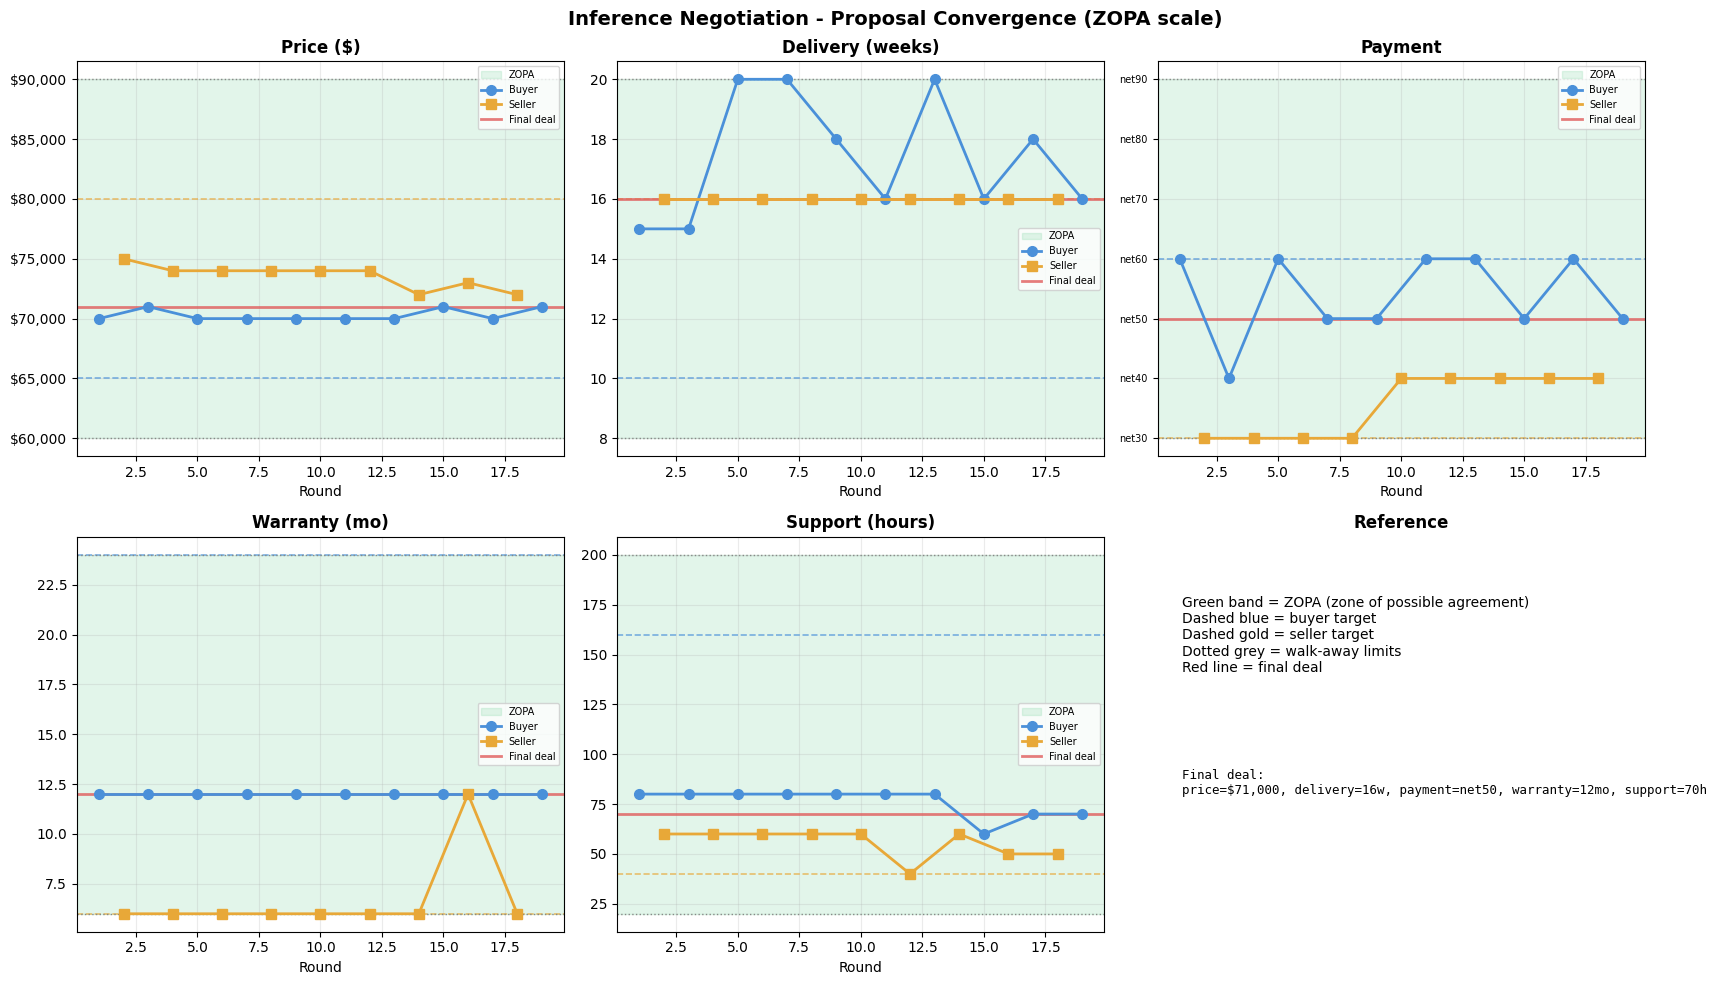

Saved -> inference_convergence.png


In [93]:
buyer_props = [e for e in result["transcript"] if e["actor"] == "Buyer" and e["action"] == "propose"]
seller_props = [e for e in result["transcript"] if e["actor"] == "Seller" and e["action"] == "propose"]

if not buyer_props and not seller_props:
    print("No proposals to plot.")
else:
    BUYER_BLUE, SELLER_GOLD, ZOPA_GREEN, DEAL_RED = "#4a90d9", "#e8a838", "#6fcf97", "#e05c5c"
    bl, sl = BUYER_TERM_SHEET["limits"], SELLER_TERM_SHEET["limits"]
    pay_idx = {term: i for i, term in enumerate(PAYMENT_ORDER)}

    # ZOPA bounds and targets per dimension (from term sheets)
    DIM_ZOPA = {
        "price": {
            "zopa_lo": min(bl["price"]["walk_away"], sl["price"]["walk_away"]),
            "zopa_hi": max(bl["price"]["walk_away"], sl["price"]["walk_away"]),
            "buyer_target": bl["price"]["target"],
            "seller_target": sl["price"]["target"],
            "fmt": "${:,.0f}",
        },
        "delivery_weeks": {
            "zopa_lo": min(bl["delivery_weeks"]["walk_away"], sl["delivery_weeks"]["walk_away"]),
            "zopa_hi": max(bl["delivery_weeks"]["walk_away"], sl["delivery_weeks"]["walk_away"]),
            "buyer_target": bl["delivery_weeks"]["target"],
            "seller_target": sl["delivery_weeks"]["target"],
            "fmt": "{}w",
        },
        "payment_terms": {
            "zopa_lo": 0,
            "zopa_hi": len(PAYMENT_ORDER) - 1,
            "buyer_target": pay_idx[bl["payment_terms"]["target"]],
            "seller_target": pay_idx[sl["payment_terms"]["target"]],
            "fmt": None,
        },
        "warranty_months": {
            "zopa_lo": min(bl["warranty_months"]["walk_away"], sl["warranty_months"]["walk_away"]),
            "zopa_hi": max(bl["warranty_months"]["walk_away"], sl["warranty_months"]["walk_away"]),
            "buyer_target": bl["warranty_months"]["target"],
            "seller_target": sl["warranty_months"]["target"],
            "fmt": "{}mo",
        },
        "support_hours": {
            "zopa_lo": min(bl["support_hours"]["walk_away"], sl["support_hours"]["walk_away"]),
            "zopa_hi": max(bl["support_hours"]["walk_away"], sl["support_hours"]["walk_away"]),
            "buyer_target": bl["support_hours"]["target"],
            "seller_target": sl["support_hours"]["target"],
            "fmt": "{}h",
        },
    }

    def _yval(dim, terms):
        return pay_idx[terms[dim]] if dim == "payment_terms" else terms[dim]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("Inference Negotiation - Proposal Convergence (ZOPA scale)", fontsize=14, fontweight="bold")
    axes = axes.flatten()

    plots = [
        ("price", "Price ($)"),
        ("delivery_weeks", "Delivery (weeks)"),
        ("payment_terms", "Payment"),
        ("warranty_months", "Warranty (mo)"),
        ("support_hours", "Support (hours)"),
    ]

    for i, (dim, title) in enumerate(plots):
        ax = axes[i]
        z = DIM_ZOPA[dim]
        pad = (z["zopa_hi"] - z["zopa_lo"]) * 0.05

        # ZOPA band and reference lines
        ax.axhspan(z["zopa_lo"], z["zopa_hi"], color=ZOPA_GREEN, alpha=0.2, zorder=0, label="ZOPA")
        ax.axhline(z["buyer_target"], color=BUYER_BLUE, ls="--", lw=1.2, alpha=0.7)
        ax.axhline(z["seller_target"], color=SELLER_GOLD, ls="--", lw=1.2, alpha=0.7)
        ax.axhline(z["zopa_lo"], color="#888", ls=":", lw=1)
        ax.axhline(z["zopa_hi"], color="#888", ls=":", lw=1)

        if buyer_props:
            br = [p["round"] for p in buyer_props]
            bv = [_yval(dim, p["terms"]) for p in buyer_props]
            ax.plot(br, bv, "o-", color=BUYER_BLUE, lw=2, markersize=7, label="Buyer", zorder=3)
        if seller_props:
            sr = [p["round"] for p in seller_props]
            sv = [_yval(dim, p["terms"]) for p in seller_props]
            ax.plot(sr, sv, "s-", color=SELLER_GOLD, lw=2, markersize=7, label="Seller", zorder=3)
        if deal:
            ax.axhline(_yval(dim, deal), color=DEAL_RED, ls="-", lw=2, alpha=0.8, label="Final deal", zorder=2)

        ax.set_ylim(z["zopa_lo"] - pad, z["zopa_hi"] + pad)
        ax.set_title(title, fontweight="bold")
        ax.set_xlabel("Round")
        ax.legend(fontsize=7, loc="best")
        ax.grid(True, alpha=0.25, zorder=1)

        if dim == "payment_terms":
            ax.set_yticks(range(len(PAYMENT_ORDER)))
            ax.set_yticklabels(PAYMENT_ORDER, fontsize=7)
        elif dim == "price":
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

    ax = axes[5]
    ax.axis("off")
    ax.set_title("Reference", fontweight="bold")
    ax.text(0.05, 0.85, "Green band = ZOPA (zone of possible agreement)\nDashed blue = buyer target\nDashed gold = seller target\nDotted grey = walk-away limits\nRed line = final deal", fontsize=10, va="top")
    if deal:
        ax.text(0.05, 0.35, f"Final deal:\n{_format_deal(deal)}", fontsize=9, family="monospace")

    plt.tight_layout()
    plt.savefig("inference_convergence.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved -> inference_convergence.png")

## Inference Evolution
How each agent's belief about the other side's priorities changed round by round, including structured 1-5 rankings.

In [94]:
inference_rows = []
for entry in result["transcript"]:
    ranks = entry.get("inferred_other_priorities", {})
    inference_rows.append({
        "Round": entry["round"],
        "Actor": entry["actor"],
        "Action": entry["action"],
        "Inferred ranking": _format_ranking(ranks) if ranks else "",
        "Inference narrative": entry.get("inference_about_other_side", ""),
        "My reasoning": entry.get("my_reasoning", ""),
    })

inference_df = pd.DataFrame(inference_rows)
display(inference_df)

print("\n--- Buyer inferred Seller priorities (by round) ---")
for e in result["transcript"]:
    if e["actor"] == "Buyer" and e.get("inferred_other_priorities"):
        print(f"R{e['round']}: {_format_ranking(e['inferred_other_priorities'])}")

print("\n--- Seller inferred Buyer priorities (by round) ---")
for e in result["transcript"]:
    if e["actor"] == "Seller" and e.get("inferred_other_priorities"):
        print(f"R{e['round']}: {_format_ranking(e['inferred_other_priorities'])}")

print(f"\nActual Seller ranking: {_format_ranking(REAL_SELLER_RANKS)}")
print(f"Actual Buyer ranking:  {_format_ranking(REAL_BUYER_RANKS)}")

,Round,Actor,Action,Inferred ranking,Inference narrative,My reasoning
0,1,Buyer,propose,Price(#1) > Warranty(#2) > Payment(#3) > Suppo...,Since I have no prior proposals to analyze yet...,I've anchored my opening offer favorably withi...
1,2,Seller,propose,Delivery(#1) > Price(#2) > Payment(#3) > Warra...,"The Buyer prioritizes price and delivery time,...",I increased the price to maintain profitabilit...
2,3,Buyer,propose,Price(#1) > Warranty(#2) > Payment(#3) > Suppo...,The Seller appears to prioritize price and may...,I moved the price down slightly while also mak...
3,4,Seller,propose,Delivery(#1) > Support(#2) > Price(#3) > Payme...,The Buyer seems to value delivery and support ...,I increased the price slightly to reflect the ...
4,5,Buyer,propose,Price(#1) > Payment(#2) > Warranty(#3) > Suppo...,The seller appears to prioritize getting a rea...,I am offering a slightly lower price and exten...
5,6,Seller,propose,Delivery(#1) > Price(#2) > Support(#3) > Payme...,The Buyer seems to prioritize delivery weeks a...,I've increased the price slightly to accommoda...
6,7,Buyer,propose,Price(#1) > Payment(#2) > Warranty(#3) > Suppo...,The seller seems to prioritize price and has h...,"I lowered the price to $70,000 to get closer t..."
7,8,Seller,propose,Delivery(#1) > Support(#2) > Price(#3) > Payme...,The buyer values delivery time highly and is f...,I am increasing the price slightly to accommod...
8,9,Buyer,propose,Price(#1) > Delivery(#2) > Payment(#3) > Warra...,The Seller seems to be prioritizing price and ...,I am reducing the price slightly to show willi...
9,10,Seller,propose,Delivery(#1) > Price(#2) > Support(#3) > Payme...,The Buyer appears to prioritize delivery and s...,I increased the price slightly to accommodate ...



--- Buyer inferred Seller priorities (by round) ---
R1: Price(#1) > Warranty(#2) > Payment(#3) > Support(#4) > Delivery(#5)
R3: Price(#1) > Warranty(#2) > Payment(#3) > Support(#4) > Delivery(#5)
R5: Price(#1) > Payment(#2) > Warranty(#3) > Support(#4) > Delivery(#5)
R7: Price(#1) > Payment(#2) > Warranty(#3) > Support(#4) > Delivery(#5)
R9: Price(#1) > Delivery(#2) > Payment(#3) > Warranty(#4) > Support(#5)
R11: Price(#1) > Delivery(#2) > Payment(#3) > Warranty(#4) > Support(#5)
R13: Price(#1) > Delivery(#2) > Payment(#3) > Warranty(#4) > Support(#5)
R15: Price(#1) > Payment(#2) > Warranty(#3) > Delivery(#4) > Support(#5)
R17: Price(#1) > Payment(#2) > Warranty(#3) > Support(#4) > Delivery(#5)
R19: Price(#1) > Delivery(#2) > Payment(#3) > Warranty(#4) > Support(#5)

--- Seller inferred Buyer priorities (by round) ---
R2: Delivery(#1) > Price(#2) > Payment(#3) > Warranty(#4) > Support(#5)
R4: Delivery(#1) > Support(#2) > Price(#3) > Payment(#4) > Warranty(#5)
R6: Delivery(#1) > Price(

## Priority Ranking Trajectory

Each agent outputs a **structured 1–5 ranking** of what they believe the other side cares about (1 = most important, 5 = least). Solid colored lines show how that estimate changed each round. **Black diamond markers** on the right mark the **actual** private ranking for each dimension (ground truth from the term sheet, never revealed to agents during negotiation).

**Mean Absolute Error (MAE)** at the bottom measures inference accuracy on the **final round only**. For each dimension, we take `|estimated rank − actual rank|`, then average across all 5 dimensions. MAE = 0 means perfect inference; MAE = 1 means off by one priority slot on average (e.g. guessed #3 when truth was #2); MAE = 2+ means the mental model is still fairly wrong.

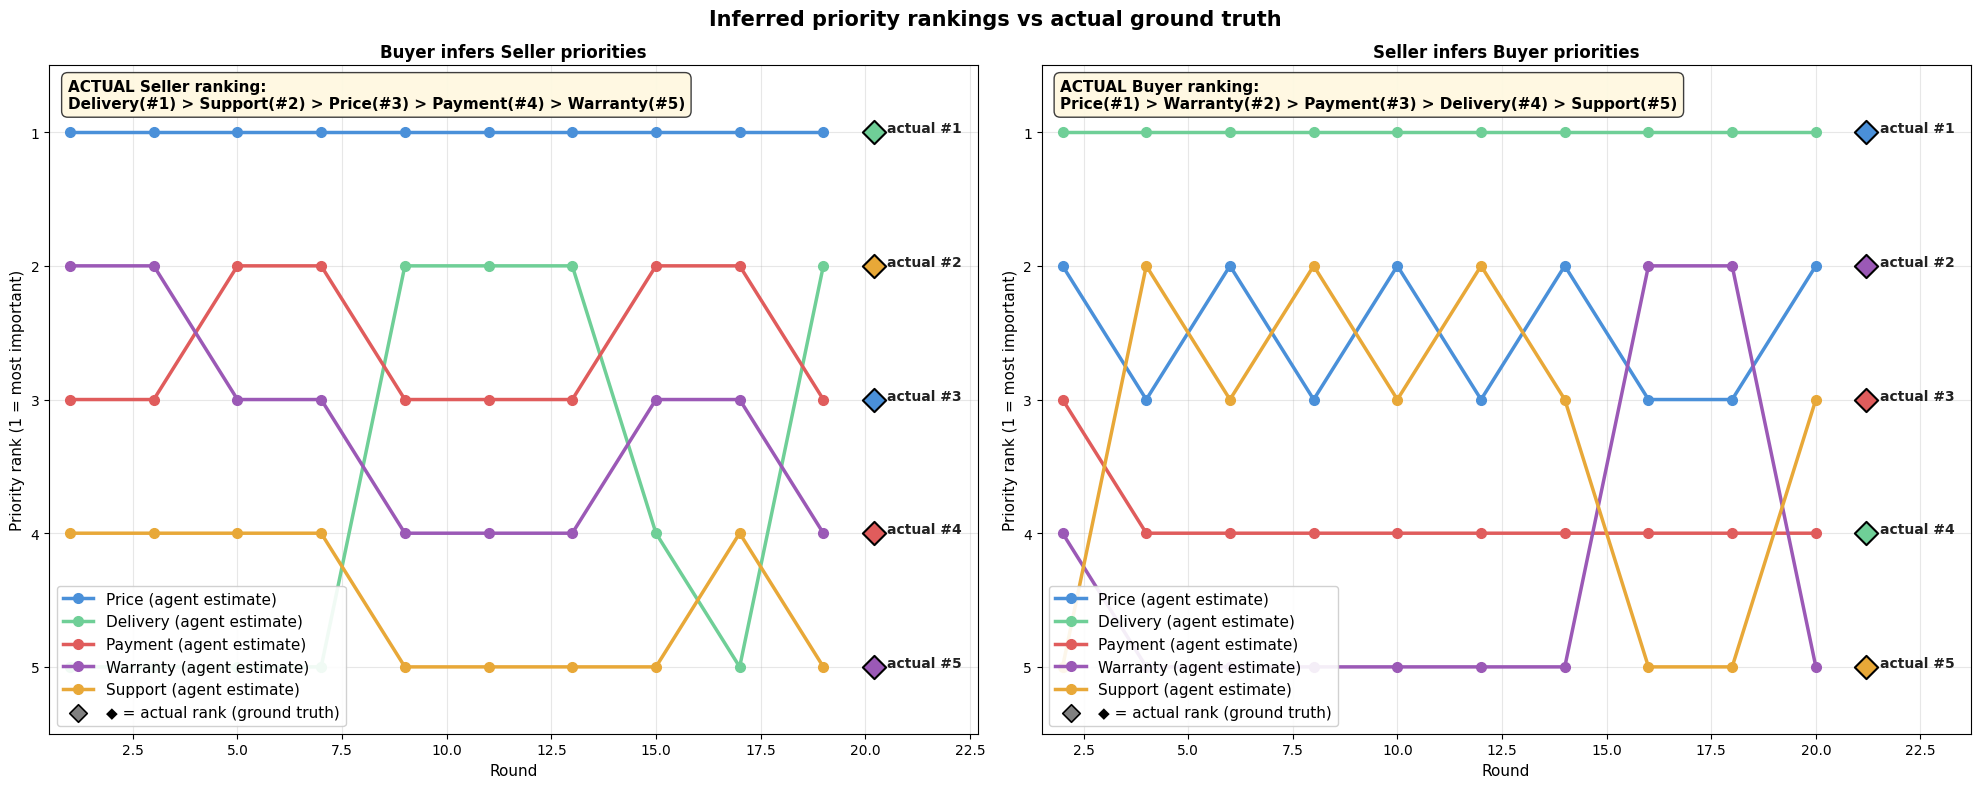

Saved -> inference_rank_trajectory.png

--- Inference accuracy (final round MAE) ---
MAE = mean |estimated rank - actual rank| across 5 dimensions (0 = perfect)

Buyer final estimate of Seller: Price(#1) > Delivery(#2) > Payment(#3) > Warranty(#4) > Support(#5)
  MAE vs actual Seller ranking: 1.60
Seller final estimate of Buyer: Delivery(#1) > Price(#2) > Support(#3) > Payment(#4) > Warranty(#5)
  MAE vs actual Buyer ranking:  2.00


In [95]:
RANK_COLORS = {
    "price": "#4a90d9",
    "delivery_weeks": "#6fcf97",
    "payment_terms": "#e05c5c",
    "warranty_months": "#9b59b6",
    "support_hours": "#e8a838",
}


def _ranking_mae(estimated: dict, actual: dict) -> float:
    """Average |estimated rank - actual rank| across all 5 dimensions."""
    return sum(abs(estimated[d] - actual[d]) for d in DIMENSIONS) / len(DIMENSIONS)


def _plot_rank_inference(ax, transcript, actor, real_ranks, other_party, title):
    """Solid lines = agent's estimated rank per dimension over rounds. Diamonds = actual ranks."""
    entries = [e for e in transcript if e["actor"] == actor and e.get("inferred_other_priorities")]
    if not entries:
        ax.set_title(title)
        ax.text(0.5, 0.5, "No ranking data", ha="center", va="center", transform=ax.transAxes)
        return

    rounds = [e["round"] for e in entries]
    x_actual = max(rounds) + 1.2

    for dim in DIMENSIONS:
        c = RANK_COLORS[dim]
        est = [e["inferred_other_priorities"][dim] for e in entries]
        ax.plot(rounds, est, "o-", color=c, lw=2.5, markersize=7,
                label=f"{DIM_LABELS[dim]} (agent estimate)")

        # Actual rank: bold diamond on right margin + label
        actual_rank = real_ranks[dim]
        ax.scatter(x_actual, actual_rank, marker="D", s=140, color=c,
                   edgecolors="black", linewidths=1.5, zorder=5)
        ax.annotate(
            f"actual #{actual_rank}",
            (x_actual, actual_rank),
            textcoords="offset points", xytext=(10, 0),
            fontsize=10, fontweight="bold", color="#222",
        )

    # Ground-truth ranking summary box
    ax.text(
        0.02, 0.98,
        f"ACTUAL {other_party} ranking:\n{_format_ranking(real_ranks)}",
        transform=ax.transAxes, va="top", fontsize=11, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#fff8e1", edgecolor="#333", alpha=0.95),
    )

    ax.set_xlim(min(rounds) - 0.5, x_actual + 2.5)
    ax.set_ylim(5.5, 0.5)  # 1 = most important at top
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.set_ylabel("Priority rank (1 = most important)", fontsize=11)
    ax.set_xlabel("Round", fontsize=11)
    ax.set_title(title, fontweight="bold", fontsize=12)
    ax.legend(fontsize=11, loc="lower left", framealpha=0.9)
    ax.grid(True, alpha=0.3)

    # Clarify what the diamonds mean
    ax.scatter([], [], marker="D", s=80, color="grey", edgecolors="black", linewidths=1.2,
               label="◆ = actual rank (ground truth)")
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, fontsize=11, loc="lower left", framealpha=0.9)


fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle("Inferred priority rankings vs actual ground truth", fontsize=15, fontweight="bold")

_plot_rank_inference(axes[0], result["transcript"], "Buyer", REAL_SELLER_RANKS, "Seller",
                       "Buyer infers Seller priorities")
_plot_rank_inference(axes[1], result["transcript"], "Seller", REAL_BUYER_RANKS, "Buyer",
                       "Seller infers Buyer priorities")

plt.tight_layout()
plt.savefig("inference_rank_trajectory.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> inference_rank_trajectory.png")

# MAE on final-round inference vs ground truth
buyer_entries = [e for e in result["transcript"] if e["actor"] == "Buyer" and e.get("inferred_other_priorities")]
seller_entries = [e for e in result["transcript"] if e["actor"] == "Seller" and e.get("inferred_other_priorities")]

print("\n--- Inference accuracy (final round MAE) ---")
print("MAE = mean |estimated rank - actual rank| across 5 dimensions (0 = perfect)\n")

if buyer_entries:
    final_buyer_est = buyer_entries[-1]["inferred_other_priorities"]
    mae = _ranking_mae(final_buyer_est, REAL_SELLER_RANKS)
    print(f"Buyer final estimate of Seller: {_format_ranking(final_buyer_est)}")
    print(f"  MAE vs actual Seller ranking: {mae:.2f}")

if seller_entries:
    final_seller_est = seller_entries[-1]["inferred_other_priorities"]
    mae = _ranking_mae(final_seller_est, REAL_BUYER_RANKS)
    print(f"Seller final estimate of Buyer: {_format_ranking(final_seller_est)}")
    print(f"  MAE vs actual Buyer ranking:  {mae:.2f}")